# Tenfold Tuning Runner

This notebook loads the setup cells from `ten_min_segment_pipeline_v10.4.ipynb`, then runs a grouped 10-fold class-weight x label-smoothing sweep with pooled out-of-fold Severe calibration.

The sweep is executed sequentially with aggressive TensorFlow and plot cleanup between folds and between weight settings to reduce CPU memory buildup.

StratifiedGroupKFold available — will use group-aware stratified splitting.


c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow 2.16.1 | NumPy 1.26.4
GPU available: False
════════════════════════════════════════════════════════════
CONFIGURATION SUMMARY
════════════════════════════════════════════════════════════
  Windows used:      Steps [2, 3]
  Sampling rate:     4 Hz raw -> 1 Hz model input
  Window length:     30 min = 1800 samples @ 1 Hz
  Canonical offsets: {2: (60, 30), 3: (30, 0)}
  Controlled windows:3 per step
    Step 2: [(70, 40), (60, 30), (50, 20)]
    Step 3: [(50, 20), (40, 10), (30, 0)]
  Max NaN frac:      16%
  CV folds:          10
  Requested min Severe/fold: 10 step-units
  Label smoothing:   0.05
  Softmax baseline:  enabled
  Feature branch:    compact engineered FHR features
  Grouped CV:        by rec_id (unchanged)
════════════════════════════════════════════════════════════
Step 2: 548 labelled records (4 uninterpretable excluded)
  Class 0 (Normal): 229 (41.8%)
  Class 1 (Mild): 251 (45.8%)
  Class 2 (Severe): 68 (12.4%)
Step 3: 337 labelled records (215 uninterpretable

Model: "FHR-SegNet-ClinFeat"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fhr_input           │ (None, 1800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_conv       │ (None, 1800, 32)  │        224 │ fhr_input[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_bn         │ (None, 1800, 32)  │        128 │ temporal_conv[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_relu       │ (None, 1800, 32)  │          0 │ temporal_bn[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 450, 32)   │          0 │ temporal_relu[0]… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 450, 32)   │          0 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_0            │ (None, 450, 32)   │      1,120 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_1            │ (None, 450, 32)   │      1,248 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_sep_2            │ (None, 450, 32)   │      1,504 │ dropout1[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_0             │ (None, 450, 32)   │        128 │ ms_sep_0[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_1             │ (None, 450, 32)   │        128 │ ms_sep_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_bn_2             │ (None, 450, 32)   │        128 │ ms_sep_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_0           │ (None, 450, 32)   │          0 │ ms_bn_0[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_1           │ (None, 450, 32)   │          0 │ ms_bn_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_relu_2           │ (None, 450, 32)   │          0 │ ms_bn_2[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_concat           │ (None, 450, 96)   │          0 │ ms_relu_0[0][0],  │
│ (Concatenate)       │                   │            │ ms_relu_1[0][0],  │
│                     │                   │            │ ms_relu_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj1 (Conv1D)      │ (None, 450, 32)   │      3,072 │ ms_concat[0][0] 

 Total params: 13,507 (52.76 KB)

 Trainable params: 13,059 (51.01 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 13,507
Training functions defined:
  train_from_scratch          - scratch training with record-step BA early stopping
  _make_model_input           - builds [X, clin] or X
  build_step_target_table     - one labeled row per record-step
  resolve_min_severe_threshold - feasible Severe threshold per fold
  oversample_minority_records - optional Severe-window oversampling
  calibrate_predictions       - optional post-hoc Severe boost
  stratified_record_kfold     - grouped CV using record-step labels
  analyze_validation_set      - fold quality assessment at record-step level
Evaluation functions defined:
  aggregate_to_record_step_level — mean probability aggregation within each record-step
  compute_metrics                — accuracy, balanced acc, macro F1, per-class
  print_metrics                  — formatted display
Plotting utilities defined (confusion matrix, fold summary)
Cross-validation pipeline defined (run_grouped_cv)
  Includes grouped CV by rec_id, train-

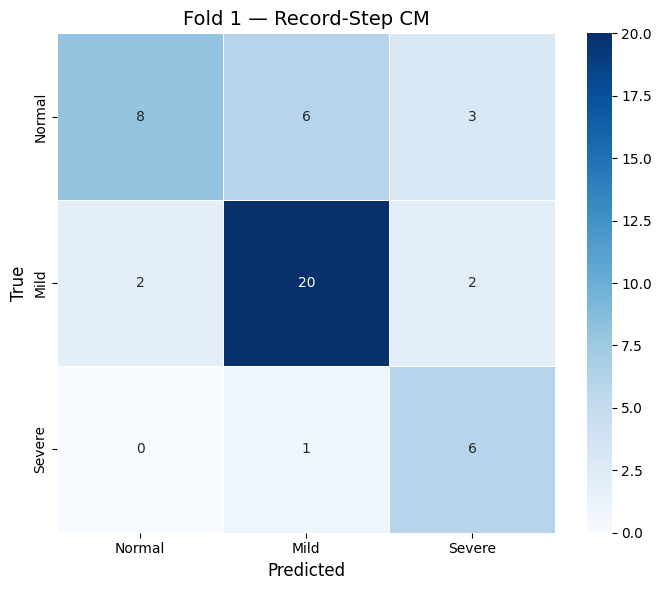


FOLD 2 / 10
  Validation quality: RELIABLE
    Normal: 26 step-units, 78 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
618/621 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4080 - loss: 1.3127  val_record_step_balanced_accuracy: 0.3175
621/621 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.4469 - loss: 1.3063 - val_accuracy: 0.3526 - val_loss: 1.0446 - val_record_step_balanced_accuracy: 0.3175 - learning_rate: 0.0010
Epoch 2/100
617/621 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4908 - loss: 1.2183  val_record_step_balanced_accuracy: 0.4086
621/621 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4911 - loss: 1.2474 - val_accuracy: 0.4359 - val_loss: 1.0295 - val_record_step_balanced_accuracy: 0.4086 - learning_rate: 0.0010
Epoch 3/100
620/621 ━━━━━━━━━━━━━━━━━━━━ 0

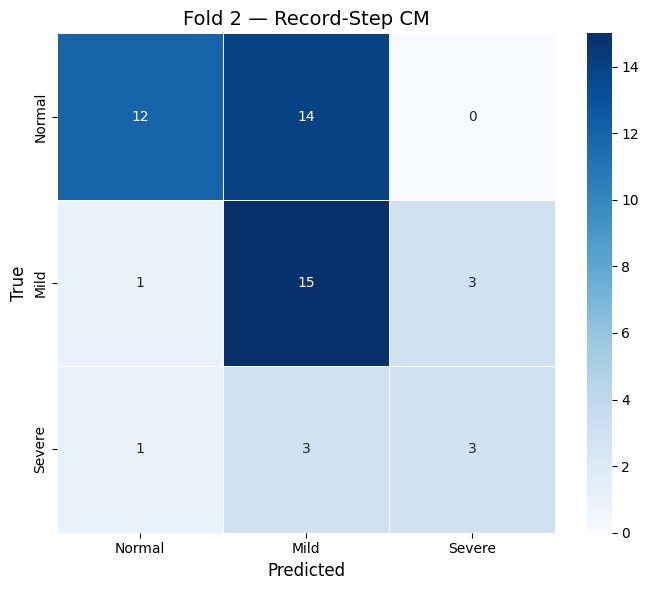


FOLD 3 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 19 step-units, 57 windows
    Severe: 7 step-units, 21 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4199 - loss: 1.3350  val_record_step_balanced_accuracy: 0.3163
636/636 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - accuracy: 0.4300 - loss: 1.2929 - val_accuracy: 0.3651 - val_loss: 1.0669 - val_record_step_balanced_accuracy: 0.3163 - learning_rate: 0.0010
Epoch 2/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4874 - loss: 1.2738  val_record_step_balanced_accuracy: 0.4599
636/636 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.5000 - loss: 1.2425 - val_accuracy: 0.5238 - val_loss: 1.0169 - val_record_step_balanced_accuracy: 0.4599 - learning_rate: 0.0010
Epoch 3/100
633/636 ━━━━━━━━━━━━━━━━━━━━ 0

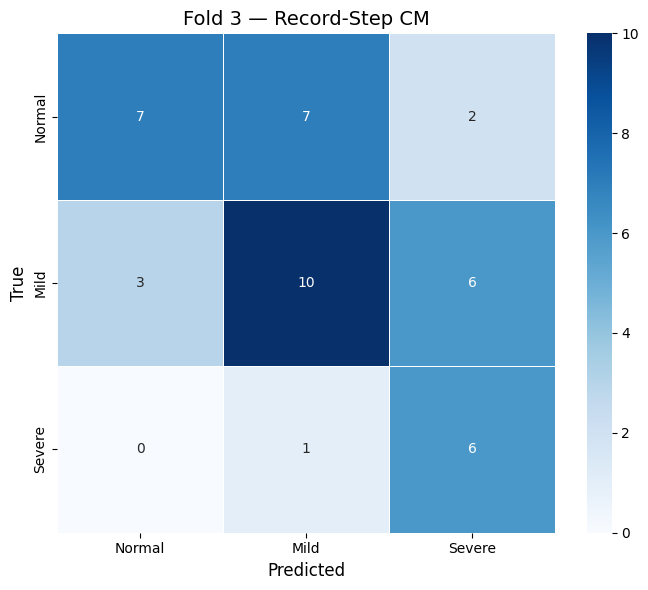


FOLD 4 / 10
  Validation quality: RELIABLE
    Normal: 11 step-units, 33 windows
    Mild: 26 step-units, 78 windows
    Severe: 8 step-units, 24 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4800 - loss: 1.2498  val_record_step_balanced_accuracy: 0.6029
632/632 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.4798 - loss: 1.2701 - val_accuracy: 0.5926 - val_loss: 0.9942 - val_record_step_balanced_accuracy: 0.6029 - learning_rate: 0.0010
Epoch 2/100
630/632 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5340 - loss: 1.1796  val_record_step_balanced_accuracy: 0.5291
632/632 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.5313 - loss: 1.2124 - val_accuracy: 0.4222 - val_loss: 1.0252 - val_record_step_balanced_accuracy: 0.5291 - learning_rate: 0.0010
Epoch 3/100
629/632 ━━━━━━━━━━━━━━━━━━━━ 0

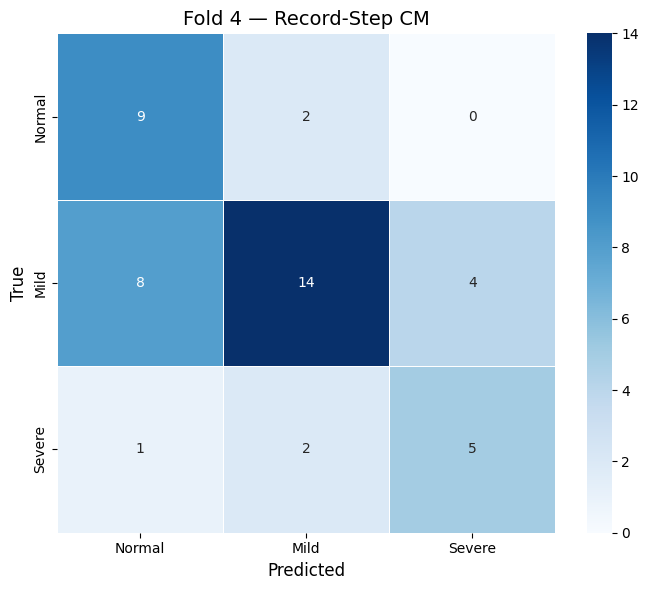


FOLD 5 / 10
  Validation quality: RELIABLE
    Normal: 16 step-units, 48 windows
    Mild: 21 step-units, 63 windows
    Severe: 5 step-units, 15 windows

TRAINING FROM SCRATCH
  Class weights (manual override): {0: 0.9, 1: 1.1, 2: 2.3}
  Early stopping monitor: val_record_step_balanced_accuracy
  Label smoothing: 0.00
Epoch 1/100
635/636 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3928 - loss: 1.3531  val_record_step_balanced_accuracy: 0.5004
636/636 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.4481 - loss: 1.2997 - val_accuracy: 0.5397 - val_loss: 0.9622 - val_record_step_balanced_accuracy: 0.5004 - learning_rate: 0.0010
Epoch 2/100
636/636 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4914 - loss: 1.2700  val_record_step_balanced_accuracy: 0.5222
636/636 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.4953 - loss: 1.2422 - val_accuracy: 0.5476 - val_loss: 0.9404 - val_record_step_balanced_accuracy: 0.5222 - learning_rate: 0.0010
Epoch 3/100
633/636 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
from pathlib import Path
import runpy

runner_path = Path('run_tenfold_tuning_from_notebook.py')
runner_globals = runpy.run_path(str(runner_path))
run_result = runner_globals['run']()

tenfold_tuning_summary_df = run_result['tenfold_tuning_summary_df']
tenfold_tuning_summaries = run_result['tenfold_tuning_summaries']
best_tenfold_run = run_result['best_tenfold_run']
best_current_weights = run_result['best_current_weights']
tenfold_tuning_output_dir = run_result['tenfold_tuning_output_dir']

tenfold_tuning_summary_df

In [ ]:
print('Best setting:')
print(f"  Manual class weights: {best_tenfold_run['manual_class_weights']}")
print(f"  Label smoothing: {best_tenfold_run['label_smoothing']:.2f}")
print(f"  OOF Severe boost: {best_tenfold_run['best_oof_severe_boost']:.2f}")
print(f"  Raw balanced accuracy: {best_tenfold_run['raw_balanced_accuracy']:.4f}")
print(f"  Calibrated balanced accuracy: {best_tenfold_run['calibrated_balanced_accuracy']:.4f}")
print(f"  Raw macro F1: {best_tenfold_run['raw_macro_f1']:.4f}")
print(f"  Calibrated macro F1: {best_tenfold_run['calibrated_macro_f1']:.4f}")
print(f"  Outputs: {tenfold_tuning_output_dir}")